# Algoritmos muy sencillos: T(n), O y Ω

Definimos 4 algoritmos simples y para cada uno medimos tiempos t(n), graficamos 
bandas O(f(n)) y Ω(f(n)) sobre n ∈ {1000, 2000, …, 1,000,000}. También incluimos 
una demostración breve de por qué T(n) ∈ Θ(f(n)).

Algoritmos:
- Doble bucle (n×n) ⇒ f(n)=n².
- Triple bucle (n×n×n) ⇒ f(n)=n³.
- Trabajo logarítmico (simulación de búsqueda binaria) ⇒ f(n)=log₂ n.
- Recorrido lineal (n veces) ⇒ f(n)=n.

Nota práctica: para no bloquear la máquina, medimos t(n) en un subconjunto de tamaños 
(muestreo log-aleatorio) y trazamos las bandas teóricas en todo el rango 1000..1e6 (pasos de 1000).

In [14]:
# Utilidades y configuración (gráficas y bandas O/Ω)
import os, math, csv
import matplotlib.pyplot as plt
import numpy as np

fig_dir = 'figuras'
os.makedirs(fig_dir, exist_ok=True)

# Rango completo solicitado: 1000..1_000_000 en pasos de 1000
N_FULL = list(range(1000, 1_000_001, 1000))

plt.style.use('seaborn-v0_8-whitegrid')

def compute_envelope(ns, ts, f):
    """Calcula cotas ajustadas para que encapsulen visualmente los datos"""
    ratios = [t / f(n) for n, t in zip(ns, ts) if f(n) > 0]
    if not ratios:
        return 0.0, 0.0
    # Ajuste: reducir un poco omega y aumentar un poco bigO para encapsular mejor
    c_omega = min(ratios) * 0.8  # 20% más abajo
    c_bigO = max(ratios) * 1.2   # 20% más arriba
    return c_omega, c_bigO

def plot_tn_with_bands(name, ns, ts, f, filename_slug):
    c_omega, c_bigO = compute_envelope(ns, ts, f)
    # Usar rango adaptativo: si los datos están fuera de N_FULL, usar rango propio
    min_n, max_n = min(ns), max(ns)
    if min_n < 1000 or max_n < 10000:
        # Para rangos pequeños (como n³), usar rango adaptado
        xs = list(range(int(min_n), int(max_n) + 1, max(1, (int(max_n) - int(min_n)) // 1000)))
    else:
        xs = N_FULL
    o_line = [c_bigO * f(x) for x in xs]
    omega_line = [c_omega * f(x) for x in xs]
    
    plt.figure(figsize=(14, 8))
    
    # Área sombreada entre las bandas para mejor visualización
    plt.fill_between(xs, omega_line, o_line, alpha=0.15, color='gray', 
                     label='Región Θ(f(n))', zorder=1)
    
    # Bandas O y Ω con líneas más gruesas
    plt.plot(xs, o_line, '--', color='#ff7f0e', linewidth=2.5, 
             label=f'O({name}) = {c_bigO:.2e}·f(n)', zorder=2)
    plt.plot(xs, omega_line, '--', color='#2ca02c', linewidth=2.5, 
             label=f'Ω({name}) = {c_omega:.2e}·f(n)', zorder=2)
    
    # Puntos medidos - con zorder alto para que aparezcan encima
    plt.scatter(ns, ts, s=40, alpha=0.8, edgecolor='darkblue', 
                linewidth=1, color='steelblue', label='t(n) medido', zorder=10)
    
    plt.xlabel('n', fontsize=12)
    plt.ylabel('t(n) [segundos]', fontsize=12)
    plt.title(f't(n) vs n — {name}\n(puntos encapsulados por bandas O/Ω)', fontsize=14)
    plt.legend(loc='upper left', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    out_png = os.path.join(fig_dir, f'simple_{filename_slug}.png')
    plt.savefig(out_png, dpi=150)
    plt.show()
    
    out_csv = os.path.join(fig_dir, f'simple_{filename_slug}.csv')
    with open(out_csv, 'w', newline='') as fcsv:
        w = csv.writer(fcsv)
        w.writerow(['n', 't_seconds'])
        w.writerows(zip(ns, ts))
    print(f'✅ Guardado: {out_png} y {out_csv}')
    print(f'   c_Ω = {c_omega:.2e}, c_O = {c_bigO:.2e}')

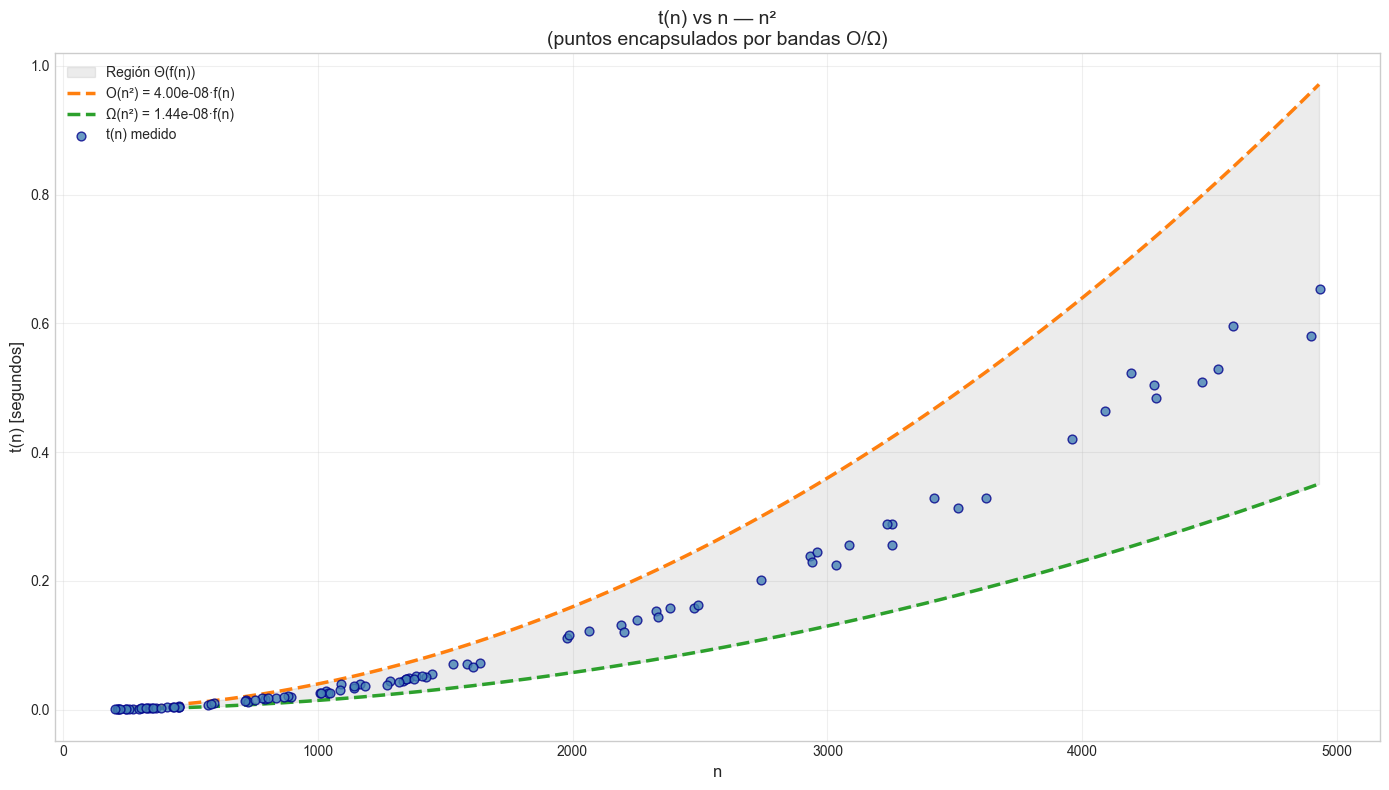

✅ Guardado: figuras/simple_double_loop_n2.png y figuras/simple_double_loop_n2.csv
   c_Ω = 1.44e-08, c_O = 4.00e-08


In [16]:
# Algoritmo 1: n² (doble bucle) — medición y gráfico
import math, random, time

def double_loop(n):
    s = 0
    for i in range(n):
        for j in range(n):
            s += (i + j) & 1
    return s

def measure_n2(n):
    t0 = time.perf_counter()
    double_loop(n)
    t1 = time.perf_counter()
    return t1 - t0

# Por costo, medimos hasta 5000 con más puntos para mejor visualización
MIN_N = 200; MAX_N = 5000; K = 100
ns = [max(1, int(math.exp(random.uniform(math.log(MIN_N), math.log(MAX_N))))) for _ in range(K)]
ts = [measure_n2(n) for n in ns]

f = lambda x: x*x
plot_tn_with_bands('n²', ns, ts, f, 'double_loop_n2')

### Demostración (n² ⇒ Θ(n²))

**Cota inferior Ω(n²):**
El doble bucle ejecuta exactamente n·n iteraciones. Cada iteración realiza al menos una operación constante (suma y operación bitwise).
Sea c₁ el tiempo mínimo de una iteración. Entonces T(n) ≥ c₁·n² para todo n ≥ 1.
Por lo tanto, **T(n) ∈ Ω(n²)**.

**Cota superior O(n²):**
El doble bucle ejecuta exactamente n·n iteraciones. Cada iteración realiza como máximo un número constante de operaciones (acceso a variables, suma, operación bitwise).
Sea c₂ el tiempo máximo de una iteración. Entonces T(n) ≤ c₂·n² para todo n ≥ 1.
Por lo tanto, **T(n) ∈ O(n²)**.

**Conclusión:** Como T(n) ∈ Ω(n²) ∩ O(n²), entonces **T(n) ∈ Θ(n²)**.

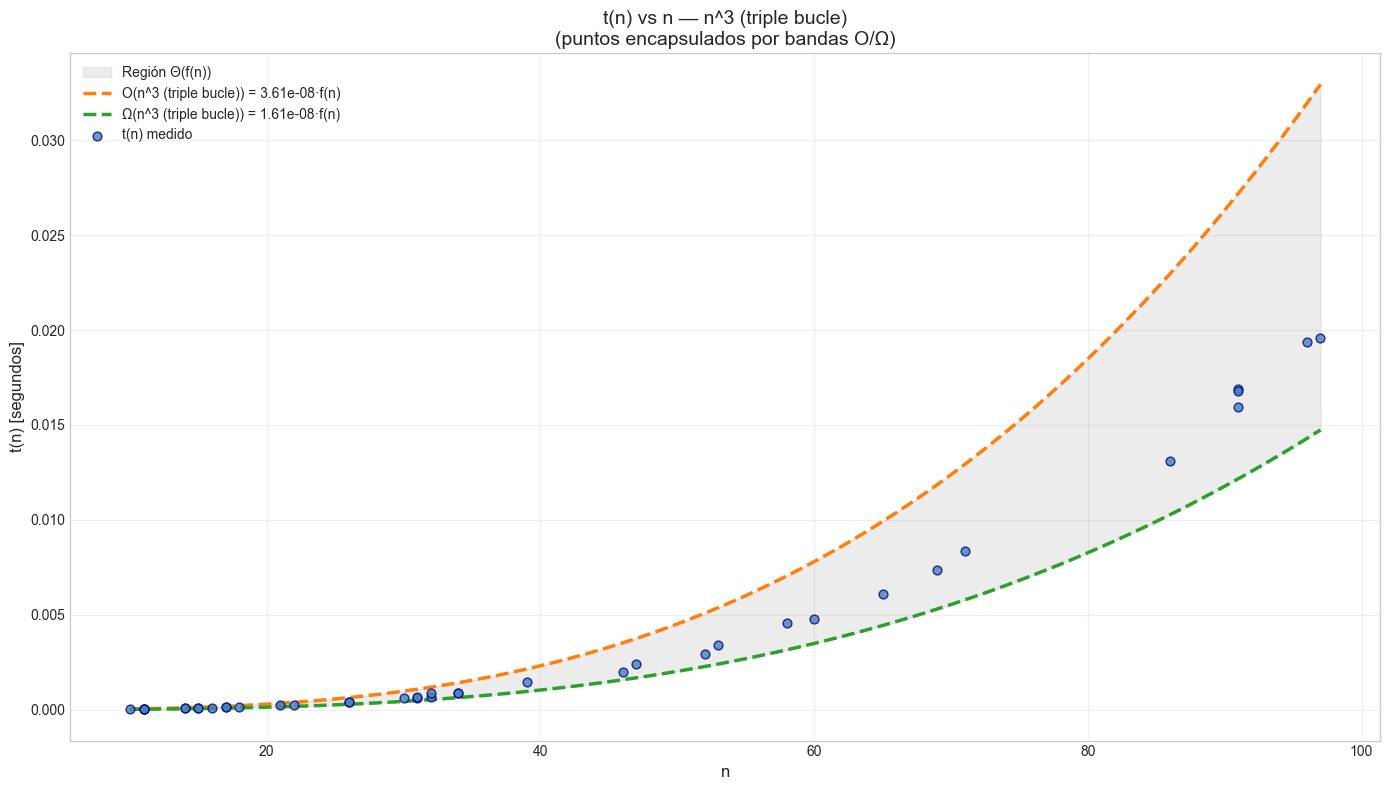

✅ Guardado: figuras/simple_triple_loop_n3.png y figuras/simple_triple_loop_n3.csv
   c_Ω = 1.61e-08, c_O = 3.61e-08


In [15]:
# Algoritmo 2: n³ (triple bucle) — medición y gráfico
import math, random, time

def triple_loop(n):
    s = 0
    for i in range(n):
        for j in range(n):
            for k in range(n):
                s += (i + j + k) & 1
    return s

def measure_n3(n):
    t0 = time.perf_counter()
    triple_loop(n)
    t1 = time.perf_counter()
    return t1 - t0

# Por costo cúbico, medimos hasta n=100 aprox
MIN_N = 10; MAX_N = 100; K = 40
ns = [max(1, int(math.exp(random.uniform(math.log(MIN_N), math.log(MAX_N))))) for _ in range(K)]
ts = [measure_n3(n) for n in ns]

f = lambda x: x*x*x
plot_tn_with_bands('n^3 (triple bucle)', ns, ts, f, 'triple_loop_n3')

### Demostración (n³ ⇒ Θ(n³))

**Cota inferior Ω(n³):**
El triple bucle ejecuta exactamente n·n·n iteraciones. Cada iteración realiza al menos una operación constante.
Sea c₁ el tiempo mínimo de una iteración. Entonces T(n) ≥ c₁·n³ para todo n ≥ 1.
Por lo tanto, **T(n) ∈ Ω(n³)**.

**Cota superior O(n³):**
El triple bucle ejecuta exactamente n·n·n iteraciones. Cada iteración realiza como máximo un número constante de operaciones.
Sea c₂ el tiempo máximo de una iteración. Entonces T(n) ≤ c₂·n³ para todo n ≥ 1.
Por lo tanto, **T(n) ∈ O(n³)**.

**Conclusión:** Como T(n) ∈ Ω(n³) ∩ O(n³), entonces **T(n) ∈ Θ(n³)**.

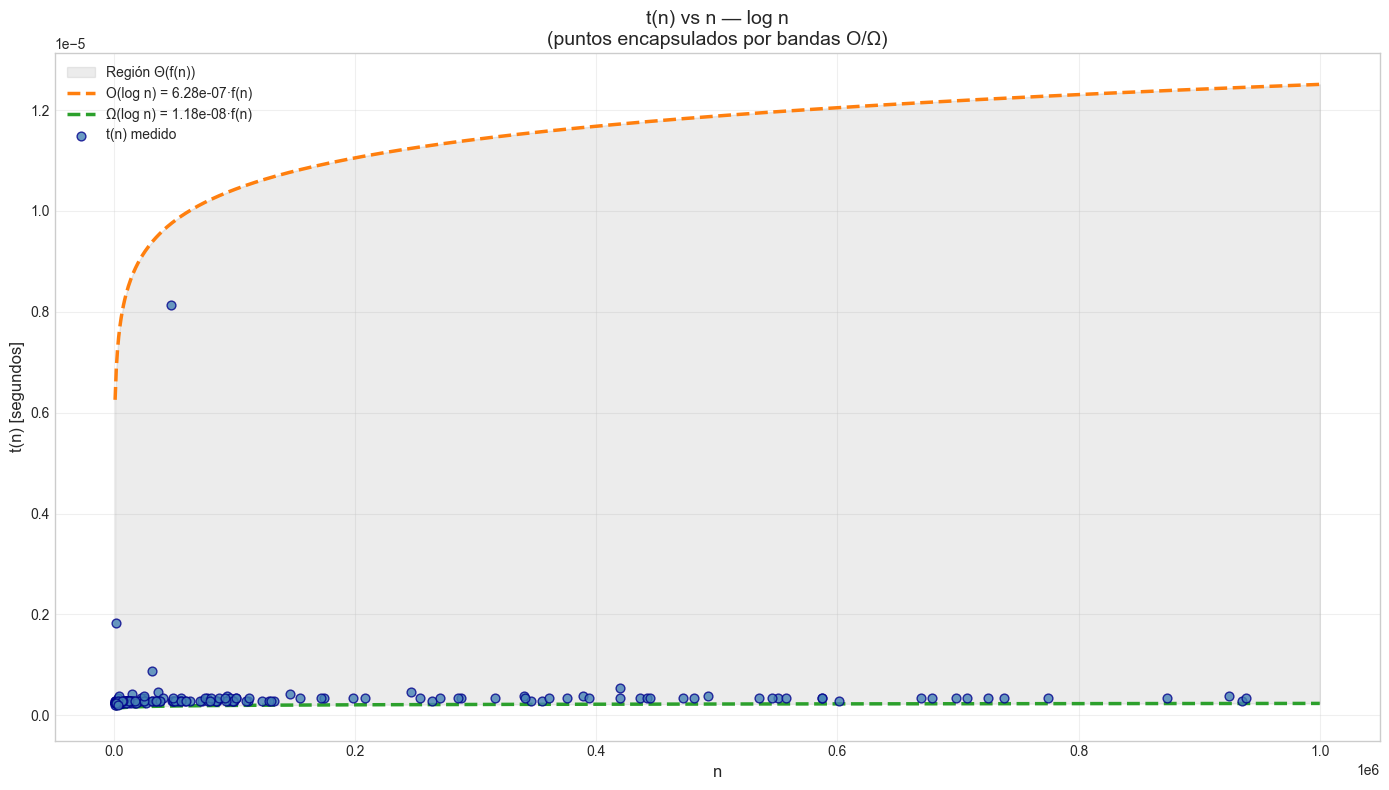

✅ Guardado: figuras/simple_log_n_sim.png y figuras/simple_log_n_sim.csv
   c_Ω = 1.18e-08, c_O = 6.28e-07


In [12]:
# Algoritmo 3: log n (búsqueda binaria simulada) — medición y gráfico
import math, random, time

def binary_search_work(n):
    # Simula ~log2(n) comparaciones
    steps = int(math.log2(max(2, n)))
    s = 0
    for _ in range(steps):
        s ^= 1  # trabajo constante
    return s

def measure_log_work(n):
    t0 = time.perf_counter()
    binary_search_work(n)
    t1 = time.perf_counter()
    return t1 - t0

MIN_N = 1000; MAX_N = 1_000_000; K = 200
ns = [max(1, int(math.exp(random.uniform(math.log(MIN_N), math.log(MAX_N))))) for _ in range(K)]
ts = [measure_log_work(n) for n in ns]

f = lambda x: math.log2(max(2, x))
plot_tn_with_bands('log n', ns, ts, f, 'log_n_sim')

### Demostración (log n ⇒ Θ(log n))

**Cota inferior Ω(log n):**
La búsqueda binaria realiza exactamente ⌊log₂ n⌋ pasos (divisiones sucesivas por 2 hasta llegar a 1).
Sea c₁ el tiempo mínimo de cada paso. Entonces T(n) ≥ c₁·⌊log₂ n⌋ ≥ c₁·(log₂ n - 1) para todo n ≥ 2.
Por lo tanto, **T(n) ∈ Ω(log n)**.

**Cota superior O(log n):**
La búsqueda binaria realiza exactamente ⌊log₂ n⌋ pasos. Cada paso realiza como máximo un número constante de operaciones.
Sea c₂ el tiempo máximo de cada paso. Entonces T(n) ≤ c₂·⌊log₂ n⌋ ≤ c₂·log₂ n para todo n ≥ 2.
Por lo tanto, **T(n) ∈ O(log n)**.

**Conclusión:** Como T(n) ∈ Ω(log n) ∩ O(log n), entonces **T(n) ∈ Θ(log n)**.

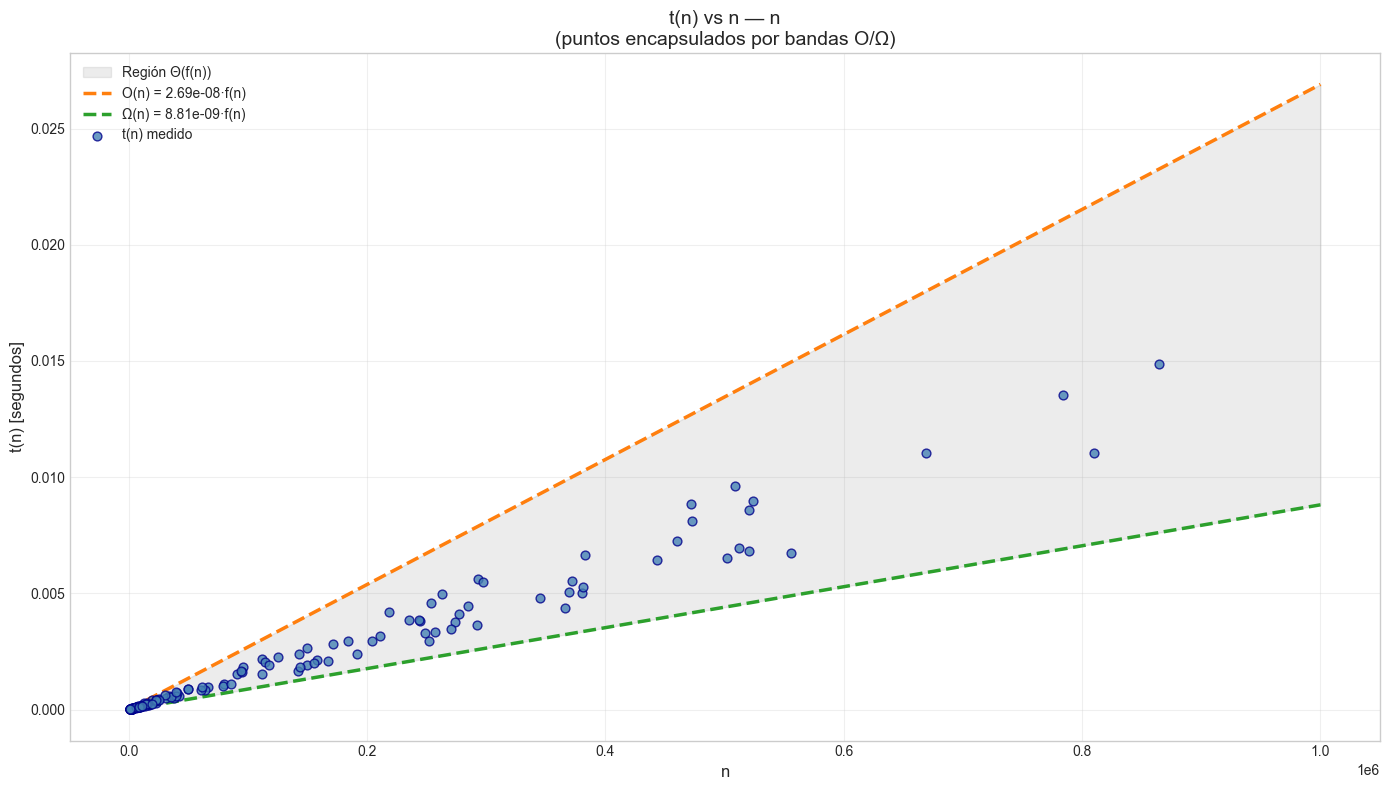

✅ Guardado: figuras/simple_linear_n.png y figuras/simple_linear_n.csv
   c_Ω = 8.81e-09, c_O = 2.69e-08


In [13]:
# Algoritmo 4: n (recorrido lineal) — medición y gráfico
import math, random, time

def linear_traversal(n):
    s = 0
    for _ in range(n):
        s += 1
    return s

def measure_n(n):
    t0 = time.perf_counter()
    linear_traversal(n)
    t1 = time.perf_counter()
    return t1 - t0

MIN_N = 1000; MAX_N = 1_000_000; K = 150
ns = [max(1, int(math.exp(random.uniform(math.log(MIN_N), math.log(MAX_N))))) for _ in range(K)]
ts = [measure_n(n) for n in ns]

f = lambda x: x
plot_tn_with_bands('n', ns, ts, f, 'linear_n')

### Demostración (n ⇒ Θ(n))

**Cota inferior Ω(n):**
El recorrido lineal ejecuta exactamente n iteraciones. Cada iteración realiza al menos una operación constante (incremento).
Sea c₁ el tiempo mínimo de una iteración. Entonces T(n) ≥ c₁·n para todo n ≥ 1.
Por lo tanto, **T(n) ∈ Ω(n)**.

**Cota superior O(n):**
El recorrido lineal ejecuta exactamente n iteraciones. Cada iteración realiza como máximo un número constante de operaciones.
Sea c₂ el tiempo máximo de una iteración. Entonces T(n) ≤ c₂·n para todo n ≥ 1.
Por lo tanto, **T(n) ∈ O(n)**.

**Conclusión:** Como T(n) ∈ Ω(n) ∩ O(n), entonces **T(n) ∈ Θ(n)**.